# AKWF Dataset Analysis & Preprocessing Pipeline

## Initialization & Data Loading

### Imports libraries

In [81]:
import pandas as pd
from typing import Dict
import numpy as np
import math
import json
import os
import gdown
import zipfile
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from scipy.io import wavfile

### Download dataset

In [39]:
# ID of file on Google Drive and URL construction
file_id = '1Bpos6HJp6IHJYIkJ0rrXhydyeiA7gREO'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'data/akwf_dataset_processed.zip'
extract_dir = 'data/AKWF_44k1_600s/AKWF_44k1_600s'

# Download dataset if it doesn't exist
if not os.path.exists(output):
    print("Downloading dataset...")
    gdown.download(url, output, quiet=False)
else:
    print("Dataset already downloaded (skipping download)")

# Extract files if the directory doesn't exist
if not os.path.exists(extract_dir):
    print("Extracting files...")
    print("May take a few minutes...")
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print("Directory with data already exists (extraction skipped)")

Dataset already downloaded (skipping download)
Directory with data already exists (extraction skipped)


### Setting up dataframe

Labels

In [40]:
def load_data(directory):
    data_list = []
    json_files = glob.glob(os.path.join(directory, "**/*.json"), recursive=True)
    for path in json_files:
        with open(path, 'r') as f:
            entry = json.load(f)
            data_list.append(entry)
    return pd.DataFrame(data_list)

df = load_data(extract_dir)

relevant_cols = [
    'name', 'duration', 'hardness', 'depth', 'brightness', 'roughness', 'warmth', 'sharpness', 'boominess', 
    'SpectralCentroid','SpectralSpread', 'SpectralKurtosis', 'ZeroCrossingRate', 'SpectralComplexity', 'OddToEvenHarmonicEnergyRatio', 
    'Dissonance', 'PitchSalience', 'HNR', 'dco_brightness','dco_richness','dco_oddenergy']

df_json = df[relevant_cols].copy()
df_json['name'] = df_json['name'].str.replace('.wav', '', case=False, regex=False)

df_json.head()

,name,duration,hardness,depth,brightness,roughness,warmth,sharpness,boominess,SpectralCentroid,...,SpectralKurtosis,ZeroCrossingRate,SpectralComplexity,OddToEvenHarmonicEnergyRatio,Dissonance,PitchSalience,HNR,dco_brightness,dco_richness,dco_oddenergy
0,AKWF_0001,0.081633,45.281085,42.934371,42.582603,54.510164,59.443373,23.618805,29.835455,0.252242,...,0.680210,0.676306,0.970149,0.017923,0.855636,0.710093,0.867728,0.286676,0.316503,0.967682
1,AKWF_0002,0.081633,43.315087,50.024872,40.883175,47.685180,62.036218,17.970129,34.846456,0.159874,...,0.746680,0.817013,0.820896,0.067929,0.645183,0.738232,0.695214,0.277888,0.298253,0.860706
2,AKWF_0003,0.081633,37.009792,51.914090,26.060335,48.370519,57.242000,10.248975,36.967382,0.092909,...,0.930015,0.676306,0.179104,0.064687,0.999089,0.437116,0.741746,0.258013,0.224493,0.867012
3,AKWF_0004,0.081633,50.695078,52.717972,45.926559,57.355137,62.477638,28.080587,34.432510,0.303827,...,0.655830,0.676306,1.000000,0.074930,0.888692,0.646194,0.684266,0.256595,0.368104,0.861705
4,AKWF_0005,0.081633,44.900469,54.564342,43.597997,47.751442,58.949869,36.140150,45.634673,0.307350,...,0.583091,0.233027,1.000000,0.899191,0.945296,0.232463,0.607288,0.119818,0.307490,0.014047


Audio files

In [41]:
dataset_path = Path("data/AKWF_44k1_600s/AKWF_44k1_600s") 

def load_dataset(path):
    files_data = []
    wav_files = list(path.rglob("*.wav"))

    for f in wav_files:
            waveform, sr = torchaudio.load(str(f), backend="soundfile")
            
            files_data.append({
                "name": f.stem,
                "waveform": waveform.squeeze(),
                "sample_rate": sr
            })

        
    return pd.DataFrame(files_data)

df_wav = load_dataset(dataset_path)
df_wav.head()

,name,waveform,sample_rate
0,AKWF_0001,"[tensor(0.0077), tensor(0.0512), tensor(0.0964...",44100
1,AKWF_0002,"[tensor(0.0009), tensor(0.0378), tensor(0.0822...",44100
2,AKWF_0003,"[tensor(0.0190), tensor(0.0574), tensor(0.0959...",44100
3,AKWF_0004,"[tensor(0.0859), tensor(0.2004), tensor(0.3104...",44100
4,AKWF_0005,"[tensor(6.1035e-05), tensor(0.0018), tensor(0....",44100


Merge

In [42]:
df = pd.merge(df_wav, df_json, on="name")
df.head()

,name,waveform,sample_rate,duration,hardness,depth,brightness,roughness,warmth,sharpness,...,SpectralKurtosis,ZeroCrossingRate,SpectralComplexity,OddToEvenHarmonicEnergyRatio,Dissonance,PitchSalience,HNR,dco_brightness,dco_richness,dco_oddenergy
0,AKWF_0001,"[tensor(0.0077), tensor(0.0512), tensor(0.0964...",44100,0.081633,45.281085,42.934371,42.582603,54.510164,59.443373,23.618805,...,0.680210,0.676306,0.970149,0.017923,0.855636,0.710093,0.867728,0.286676,0.316503,0.967682
1,AKWF_0002,"[tensor(0.0009), tensor(0.0378), tensor(0.0822...",44100,0.081633,43.315087,50.024872,40.883175,47.685180,62.036218,17.970129,...,0.746680,0.817013,0.820896,0.067929,0.645183,0.738232,0.695214,0.277888,0.298253,0.860706
2,AKWF_0003,"[tensor(0.0190), tensor(0.0574), tensor(0.0959...",44100,0.081633,37.009792,51.914090,26.060335,48.370519,57.242000,10.248975,...,0.930015,0.676306,0.179104,0.064687,0.999089,0.437116,0.741746,0.258013,0.224493,0.867012
3,AKWF_0004,"[tensor(0.0859), tensor(0.2004), tensor(0.3104...",44100,0.081633,50.695078,52.717972,45.926559,57.355137,62.477638,28.080587,...,0.655830,0.676306,1.000000,0.074930,0.888692,0.646194,0.684266,0.256595,0.368104,0.861705
4,AKWF_0005,"[tensor(6.1035e-05), tensor(0.0018), tensor(0....",44100,0.081633,44.900469,54.564342,43.597997,47.751442,58.949869,36.140150,...,0.583091,0.233027,1.000000,0.899191,0.945296,0.232463,0.607288,0.119818,0.307490,0.014047


## Data Integrity Check - Labels

### Check for missing values 

In [43]:
missing_info = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_info,
    'Percentage (%)': missing_percent
})

# Filter only columns that have at least one missing value
missing_summary = missing_df[missing_df['Missing Values'] > 0]

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print("WARNING: Found missing values:")
    display(missing_summary)

No missing values found in the dataset.


### Check for duplicate records 

In [44]:
check_cols = [col for col in df.columns if col not in ['name', 'waveform', 'sample_rate', 'duration']]

content_duplicates = df.duplicated(subset=check_cols, keep=False).sum()

if content_duplicates > 0:
    print(f"WARNING: Found {content_duplicates} rows with identical data content.")
    
else:
    print("No identical data rows found. Each waveform has unique features.")

In [45]:
# Remove duplicates based on content
dflen_before = len(df)
df = df.drop_duplicates(subset=check_cols, keep='first')
print(f"Duplicates removed. Final dataset size: {len(df)} samples (originally {dflen_before}).")


Duplicates removed. Final dataset size: 4154 samples (originally 4158).


### Check for data types of each column

In [46]:
print("\nColumn Data Types:")
display(df.dtypes)


Column Data Types:


name                             object
waveform                         object
sample_rate                       int64
duration                        float64
hardness                        float64
depth                           float64
brightness                      float64
roughness                       float64
warmth                          float64
sharpness                       float64
boominess                       float64
SpectralCentroid                float64
SpectralSpread                  float64
SpectralKurtosis                float64
ZeroCrossingRate                float64
SpectralComplexity              float64
OddToEvenHarmonicEnergyRatio    float64
Dissonance                      float64
PitchSalience                   float64
HNR                             float64
dco_brightness                  float64
dco_richness                    float64
dco_oddenergy                   float64
dtype: object

### Check integrity of sample rate and duration

In [47]:
sr_unique_count = df['sample_rate'].nunique()
dur_unique_count = df['duration'].nunique()

if sr_unique_count == 1 and dur_unique_count == 1:
    print(f"Technical Integrity Verified:")
    print(f" - All samples have Samplerate: {df['sample_rate'].iloc[0]} Hz")
    print(f" - All samples have Duration: {df['duration'].iloc[0]} s")
else:
    print("Warning: Inconsistent technical specifications found!")

Technical Integrity Verified:
 - All samples have Samplerate: 44100 Hz
 - All samples have Duration: 0.08163265138864517 s


## Data Integrity Check - Audio Files

In [48]:
is_uniform = df['waveform'].apply(lambda x: x.shape[0]).nunique() == 1
if is_uniform:
    print("All audio files have the same length.")
else:
    print("Warning: Audio files have varying lengths.")

All audio files have the same length.


Important for the proper functionality of the CVAE – all data must have a uniform length for the model to work.

In [49]:
peaks = df['waveform'].apply(lambda x: x.abs().max().item())

print(f"Minimum Peak: {peaks.min():.4f}")
print(f"Maximum Peak: {peaks.max():.4f}")
print(f"Average Peak: {peaks.mean():.4f}")

low_volume = (peaks < 0.9).sum()
if low_volume > 0:
    print(f"\nWarning: {low_volume} samples are below 0.9 peak.")
else:
    print("\nAll samples are consistently normalized near 1.0.")

Minimum Peak: 0.3536
Maximum Peak: 1.0000
Average Peak: 0.9949



Within a dataset of 4,158 samples, 79 is a negligible number – however, normalization is still appropriate.

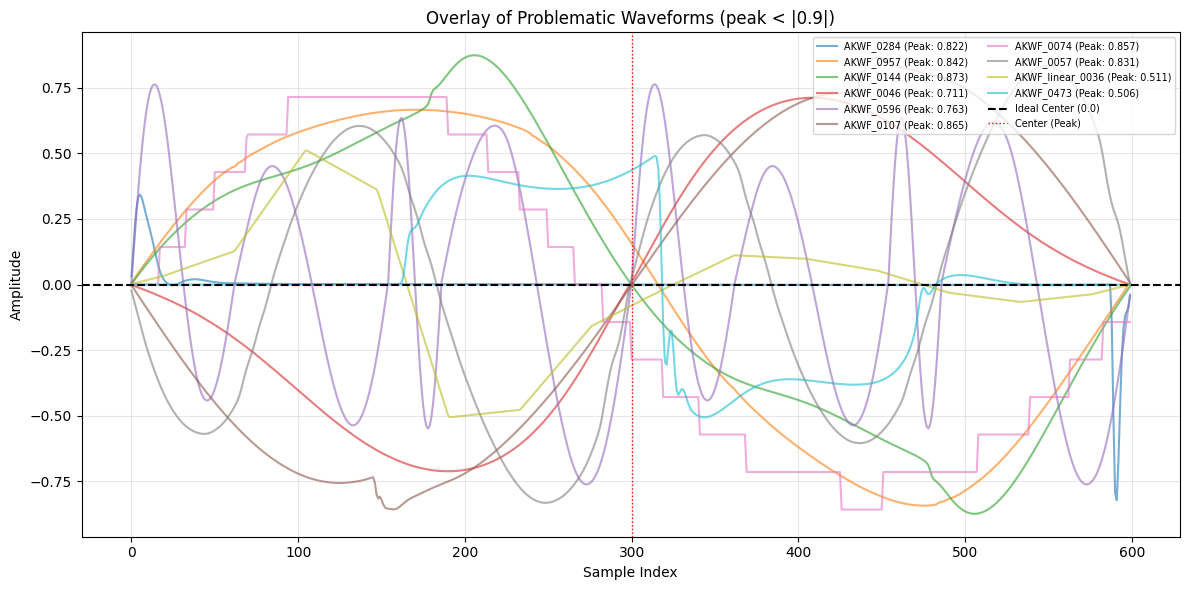

In [50]:
def plot_problematic_waves(df, peaks, threshold=0.9, max_samples=10):
    problematic_mask = peaks.abs() < threshold
    problematic_df = df[problematic_mask]
    num_problematic = len(problematic_df)
    
    if num_problematic == 0:
        print(f"No waveforms fall below the threshold of {threshold}.")
        return

    plt.figure(figsize=(12, 6))
    
    samples_to_plot = problematic_df.sample(min(num_problematic, max_samples))
    
    for i, (idx, row) in enumerate(samples_to_plot.iterrows()):
        waveform = row['waveform'].numpy()
        offset_val = peaks.loc[idx]
        label_name = row.get('name', f"Index: {idx}") + f" (Peak: {offset_val:.3f})"
        
        plt.plot(waveform, alpha=0.6, label=label_name)

    plt.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Ideal Center (0.0)')
    plt.axvline(300, color='red', linewidth=1, linestyle=':', label='Center (Peak)')
    plt.title(f"Overlay of Problematic Waveforms (peak < |{threshold}|)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right', fontsize='x-small', ncol=2)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_problematic_waves(df, peaks, threshold=0.9, max_samples=10)

Normalization algorithms function by scaling audio signals based on their maximum absolute peak amplitude. When a waveform exhibits a DC offset, it is physically asymmetrical relative to the zero axis. Applying normalization to such a signal inherently amplifies the DC offset alongside the intended acoustic data. 

Consequently, if DC offset correction is performed after normalization, the entire waveform is shifted back to true zero. This spatial realignment alters the previously established peak amplitudes, rendering the initial normalization invalid and necessitating a secondary computational pass. 

In [51]:
offs = df['waveform'].apply(lambda x: x.mean().item())

print(f"Minimum Offset: {offs.min():.6f}")
print(f"Maximum Offset: {offs.max():.6f}")
print(f"Average Offset: {offs.mean():.6f}")

threshold = 0.01
problematic = (offs.abs() > threshold).sum()

if problematic > 0:
    print(f"\nAWarning: {problematic} samples have a DC Offset (> {threshold}).")
else:
    print(f"\nDC Offset is negligible. Your waveforms are well-centered.")

Minimum Offset: -0.816898
Maximum Offset: 0.971070
Average Offset: -0.000084



DC offset means that an audio waveform is not perfectly centered around zero. Although this shift is inaudible on its own, it causes several issues during audio processing:

* **Loss of headroom and clipping:** An offset wave hits the digital ceiling (0 dBFS) much earlier, leading to premature clipping and unwanted distortion.
* **Clicks and pops during editing:** Because the waveform doesn't rest at true zero, cutting or splicing the audio creates abrupt jumps in amplitude, resulting in loud, audible clicks.
* **Inaccurate effect processing:** An asymmetrical signal confuses threshold-dependent effects (like compressors and limiters) and alters the intended character of distortion or saturation.
* **Physical strain on hardware:** Speakers are constantly forced into an unnatural resting position, which reduces their low-frequency efficiency and puts unnecessary stress on the components.


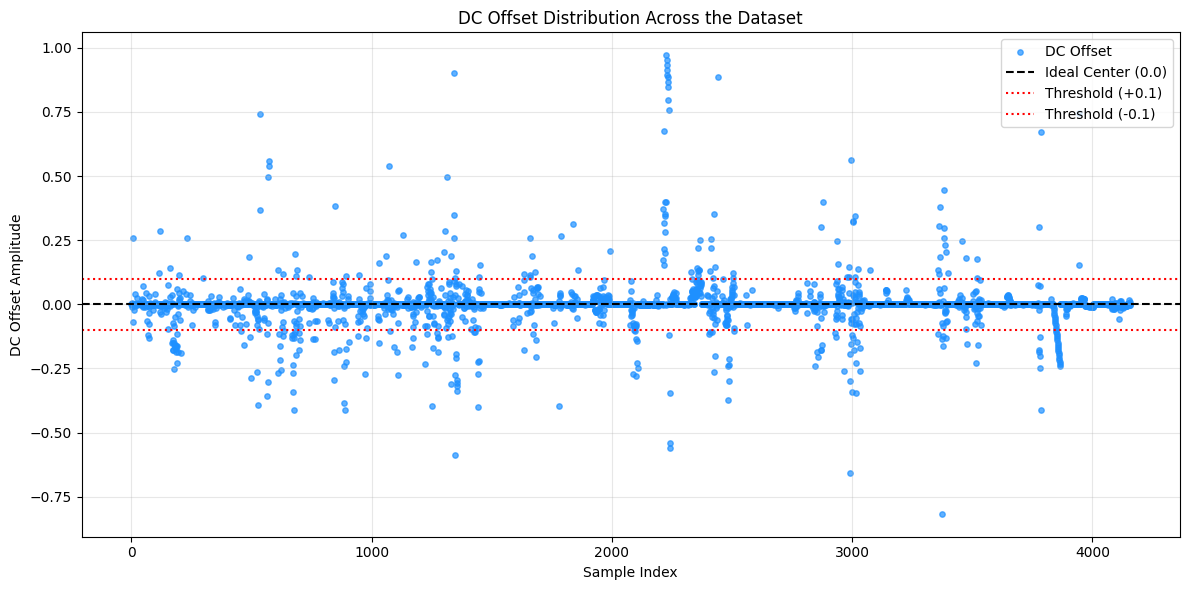

In [52]:
def plot_dc_offsets(dc_offsets, threshold=0.1):
    plt.figure(figsize=(12, 6))
    
    plt.scatter(dc_offsets.index, dc_offsets.values, alpha=0.7, s=15, label='DC Offset', color='dodgerblue')

    plt.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Ideal Center (0.0)')
    
    # boundaries
    plt.axhline(threshold, color='red', linewidth=1.5, linestyle=':', label=f'Threshold (+{threshold})')
    plt.axhline(-threshold, color='red', linewidth=1.5, linestyle=':', label=f'Threshold (-{threshold})')
    
    plt.title("DC Offset Distribution Across the Dataset")
    plt.xlabel("Sample Index")
    plt.ylabel("DC Offset Amplitude")
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_dc_offsets(offs, threshold=0.1)

Minimum Offset: -0.816898
Maximum Offset: 0.971070
Average Offset: -0.000084



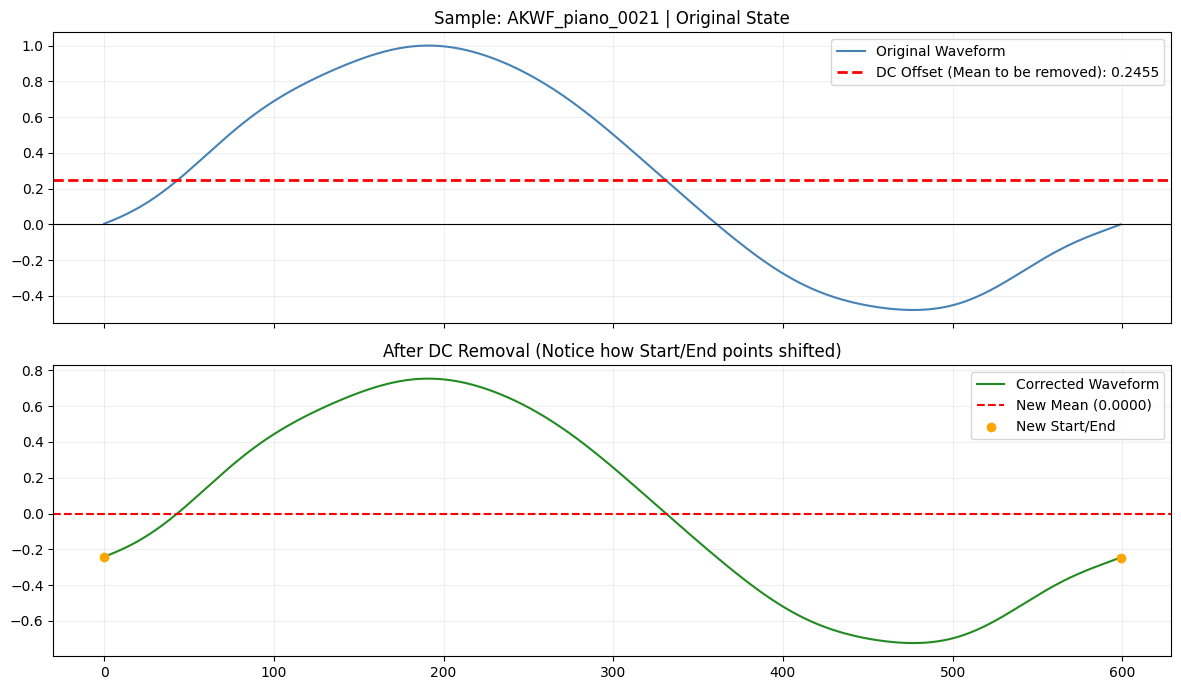

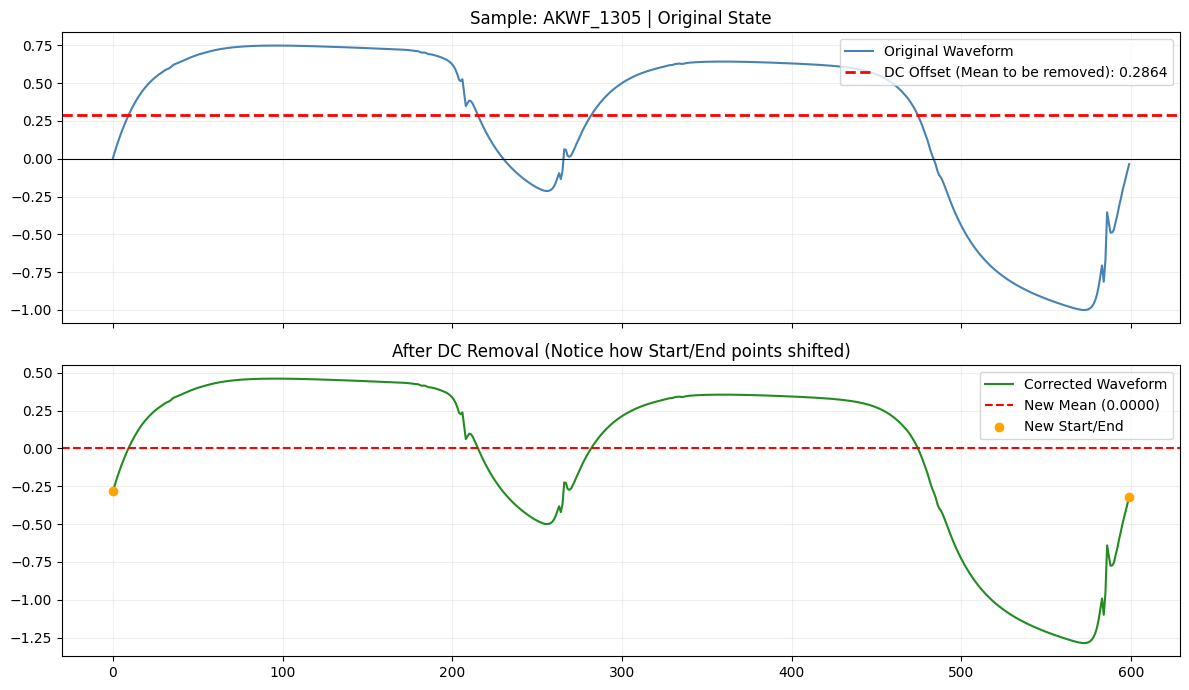

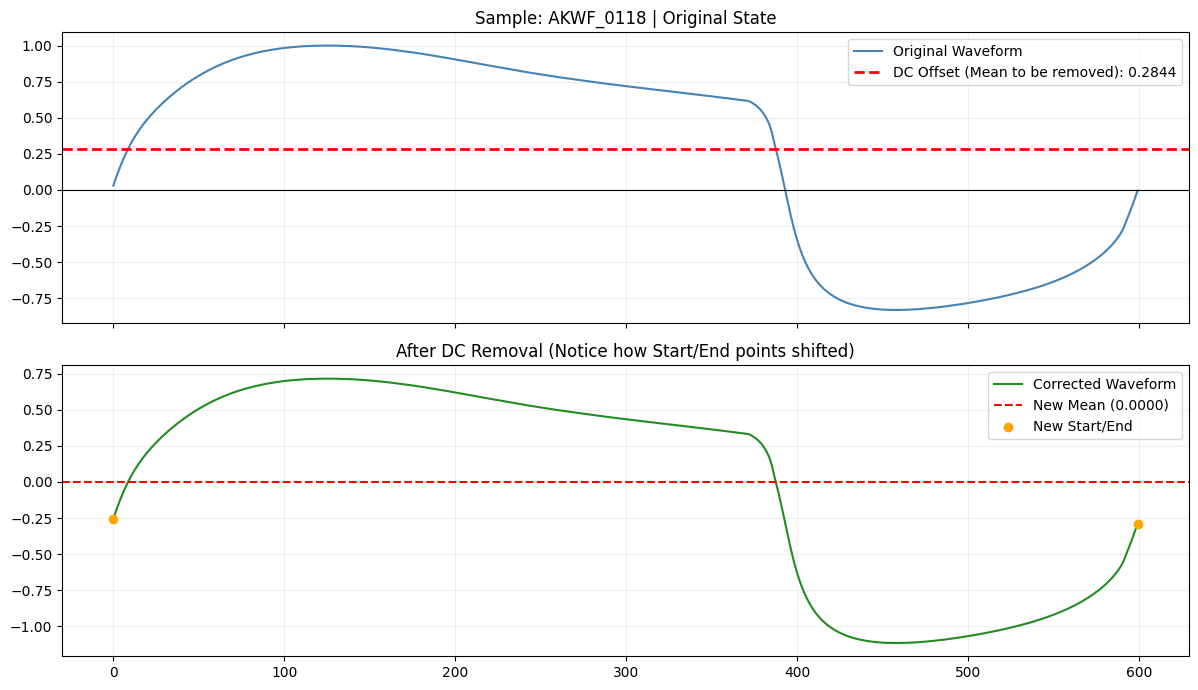

In [53]:
offs = df['waveform'].apply(lambda x: x.mean().item())

print(f"Minimum Offset: {offs.min():.6f}")
print(f"Maximum Offset: {offs.max():.6f}")
print(f"Average Offset: {offs.mean():.6f}")

threshold = 0.1
problematic_mask = offs.abs() > threshold
problematic_count = problematic_mask.sum()

if problematic_count > 0:
    print(f"\nWarning: {problematic_count} samples have a significant DC Offset (> {threshold}).")
    samples_to_plot = df[problematic_mask].sample(min(3, problematic_count))
    for idx, row in samples_to_plot.iterrows():
        wv = row['waveform']
        mean_val = wv.mean().item()
        corrected_wv = wv - mean_val
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        
        ax1.plot(wv.numpy(), color='steelblue', label='Original Waveform')
        ax1.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, 
                    label=f'DC Offset (Mean to be removed): {mean_val:.4f}')
        ax1.axhline(0, color='black', linewidth=0.8)
        ax1.set_title(f"Sample: {row.get('name', idx)} | Original State")
        ax1.legend(loc='upper right')
        ax1.grid(alpha=0.2)
        
        ax2.plot(corrected_wv.numpy(), color='forestgreen', label='Corrected Waveform')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, label='New Mean (0.0000)')
        ax2.scatter([0, 599], [corrected_wv[0], corrected_wv[-1]], color='orange', zorder=5, label='New Start/End')
        
        ax2.set_title("After DC Removal (Notice how Start/End points shifted)")
        ax2.legend(loc='upper right')
        ax2.grid(alpha=0.2)
        
        plt.tight_layout()
        plt.show() 
else:
    print(f"\nDC Offset is negligible. Your waveforms are well-centered.")
    samples_to_plot = df.sample(3)

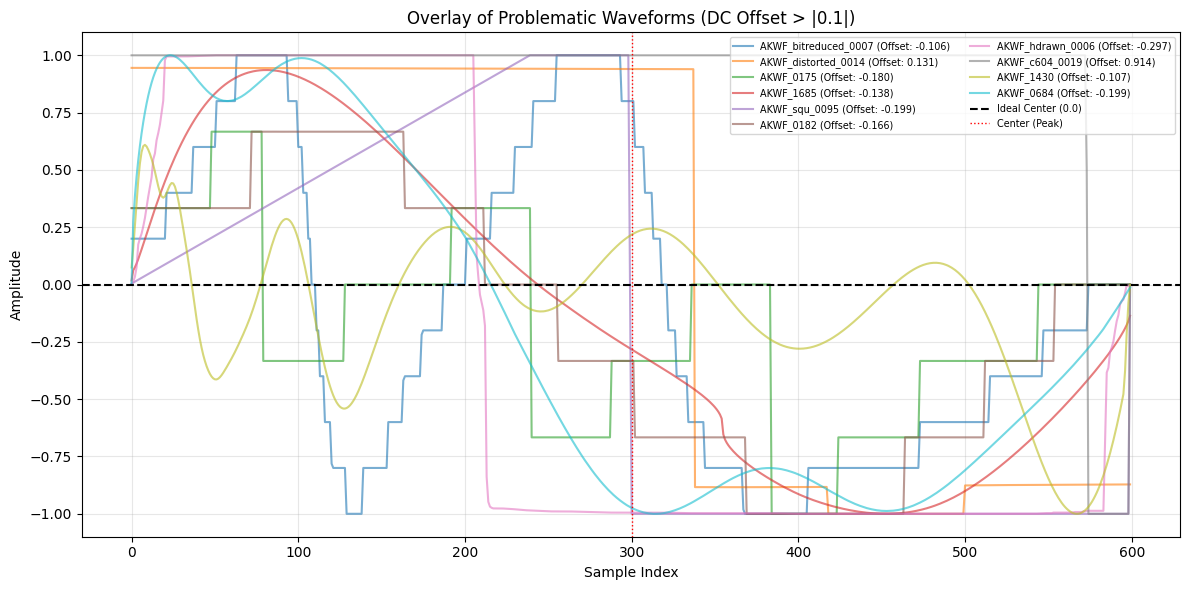

In [54]:
def plot_problematic_waves(df, dc_offsets, threshold=0.1, max_samples=10):
    problematic_mask = dc_offsets.abs() > threshold
    problematic_df = df[problematic_mask]
    num_problematic = len(problematic_df)
    
    if num_problematic == 0:
        print(f"No waveforms exceed the DC offset threshold of {threshold}.")
        return

    plt.figure(figsize=(12, 6))
    
    samples_to_plot = problematic_df.sample(min(num_problematic, max_samples))
    
    for i, (idx, row) in enumerate(samples_to_plot.iterrows()):
        waveform = row['waveform'].numpy()
        offset_val = dc_offsets.loc[idx]
        label_name = row.get('name', f"Index: {idx}") + f" (Offset: {offset_val:.3f})"
        
        plt.plot(waveform, alpha=0.6, label=label_name)

    plt.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Ideal Center (0.0)')
    plt.axvline(300, color='red', linewidth=1, linestyle=':', label='Center (Peak)')
    plt.title(f"Overlay of Problematic Waveforms (DC Offset > |{threshold}|)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right', fontsize='x-small', ncol=2)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_problematic_waves(df, offs, threshold=0.1, max_samples=10)

In [55]:
def peak_normalize(waveform):
    peak = waveform.abs().max()
    if peak > 0:
        return waveform / peak
    return waveform

df['waveform'] = df['waveform'].apply(lambda x: x - x.mean())
df['waveform'] = df['waveform'].apply(peak_normalize)

print(f"Normalization and DC offset correction complete.")

Normalization and DC offset correction complete.


It is crucial to realize that almost all waves in the dataset are already normalized. By removing the DC offset, the dataset must be re-normalized, plus the shift will likely create samples that neither start nor end at zero.

In [56]:
loop_diff = df['waveform'].apply(lambda x: (abs(x[0]) - abs(x[-1])).abs().item())

print(f"Max Difference: {loop_diff.max():.6f}")
print(f"Average Difference: {loop_diff.mean():.6f}")

threshold = 0.05
bad_loops = (loop_diff > threshold).sum()

if bad_loops > 0:
    print(f"\nWarning: {bad_loops} samples have a potential 'click' (diff > {threshold}).")
else:
    print("\nMost samples are well-aligned for looping.")

Max Difference: 1.000000
Average Difference: 0.084607



In [57]:

threshold = 0.05

loop_diff = df['waveform'].apply(lambda x: (abs(x[0]) - abs(x[-1])).abs().item())


df_clean = df[loop_diff <= threshold].copy()
df_clean.reset_index(drop=True, inplace=True)

# Calculate and print the summary
removed_count = len(df) - len(df_clean)
print(f"Original dataset size: {len(df)} samples")
print(f"Removed problematic loops: {removed_count} samples (diff > {threshold})")
print(f"New clean dataset size: {len(df_clean)} samples")

df = df_clean

Original dataset size: 4154 samples
Removed problematic loops: 1017 samples (diff > 0.05)
New clean dataset size: 3137 samples


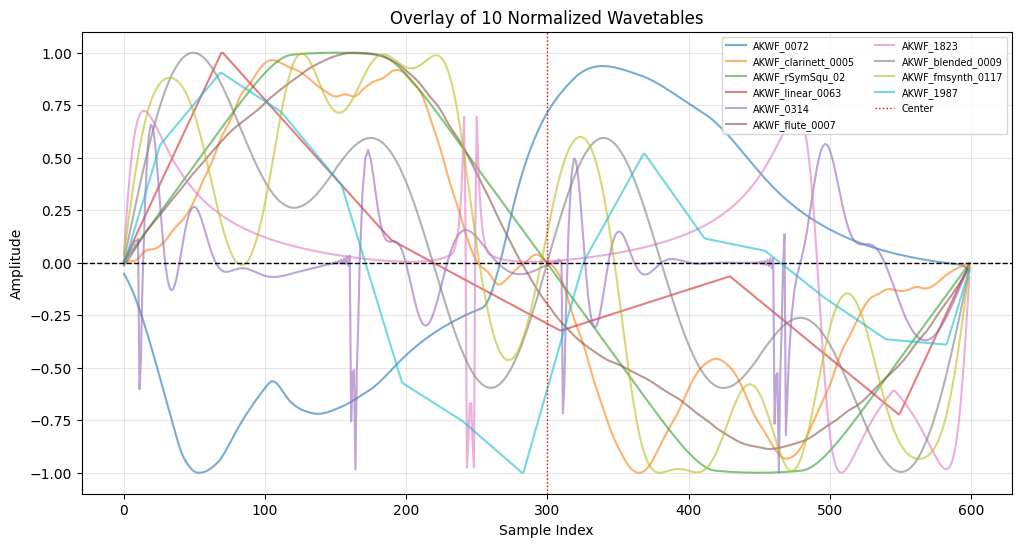

In [58]:
def plot_processed_waves(df, num_samples=10):
    plt.figure(figsize=(12, 6))
    
    samples = df.sample(num_samples)
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        waveform = row['waveform'].numpy()

        label_name = row.get('name', f"Index: {idx}")
        plt.plot(waveform, alpha=0.6, label=label_name)

    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.axvline(300, color='red', linewidth=1, linestyle=':', label='Center')
    
    plt.title(f"Overlay of {num_samples} Normalized Wavetables")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right', fontsize='x-small', ncol=2)
    plt.grid(alpha=0.3)
    plt.show()


plot_processed_waves(df)

## Analysis

### Range Check

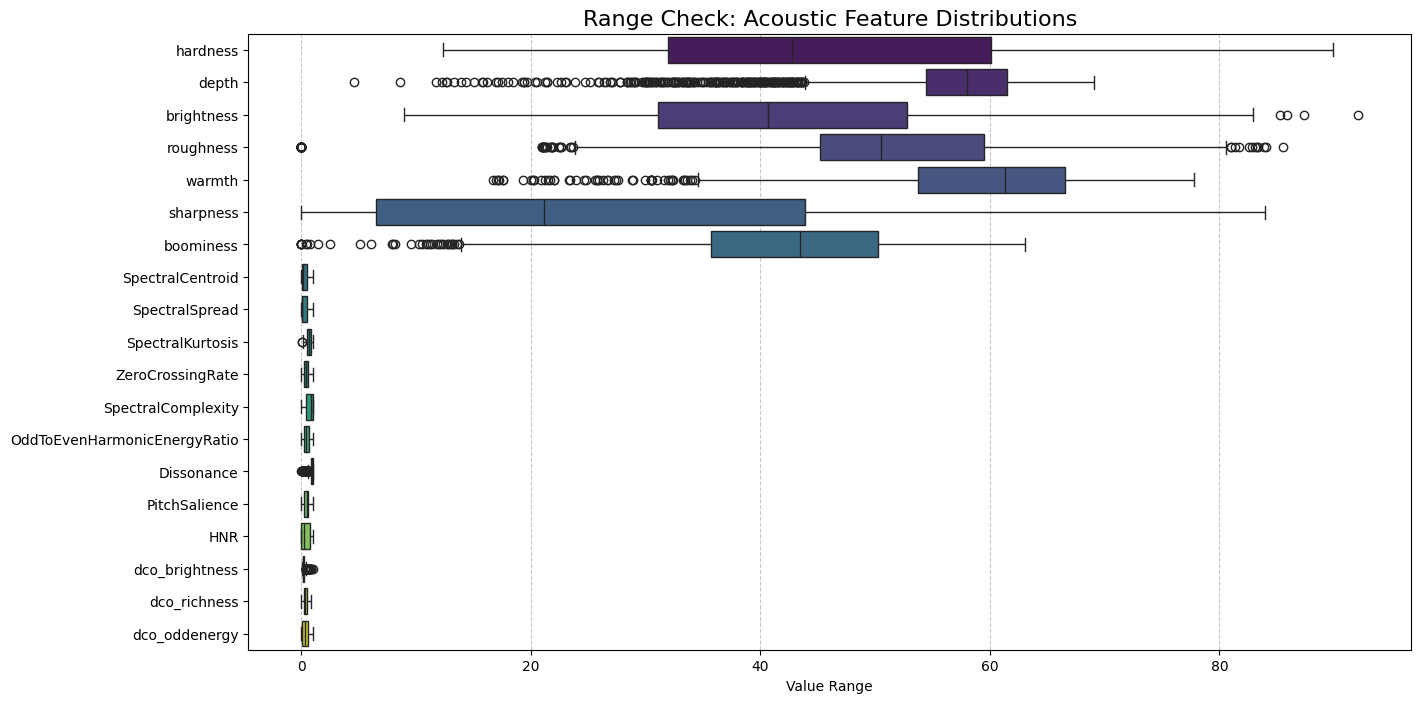

In [59]:
exclude_cols = ['name', 'waveform', 'sample_rate', 'duration']

# 1. Select only the acoustic features (excluding constants and names)
acoustic_features = df.drop(columns=[c for c in exclude_cols if c in df.columns])

# 2. Plotting the ranges
plt.figure(figsize=(15, 8))
sns.boxplot(data=acoustic_features, orient='h', palette='viridis')

# 3. Customizing the plot
plt.title("Range Check: Acoustic Feature Distributions", fontsize=16)
plt.xlabel("Value Range")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

It is clear that some values are normalized within the 0-1 range, while others are not. The challenge is that there is no documentation regarding how these attributes were computed. Therefore, it is necessary to validate the attributes. 

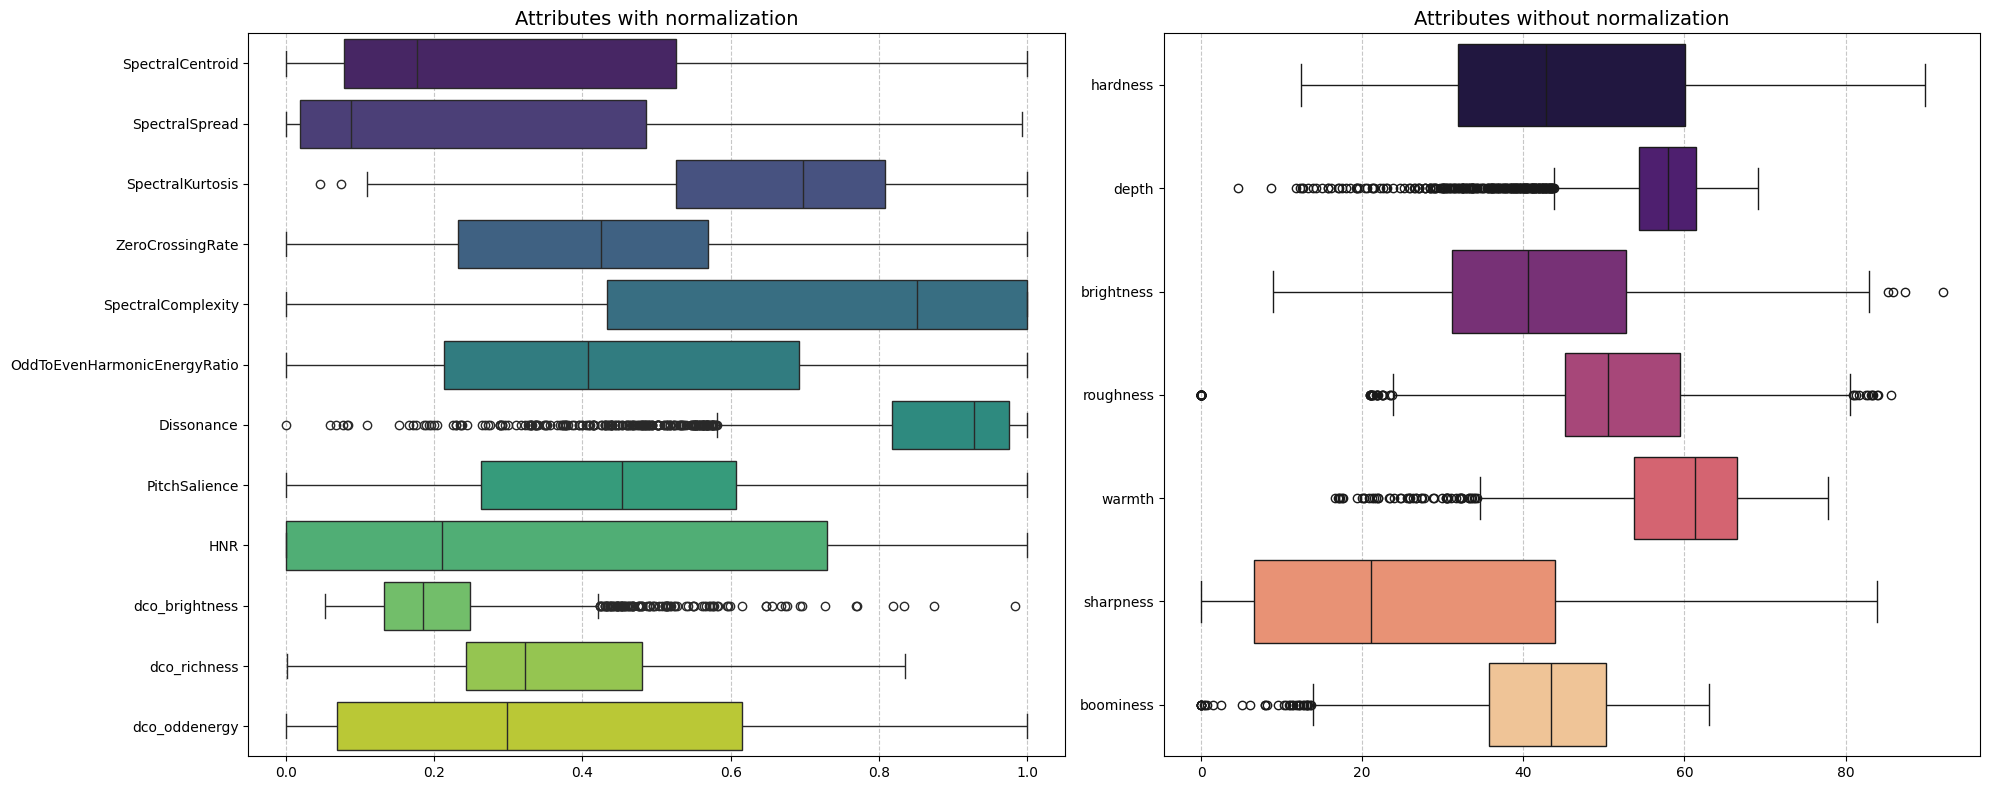

In [60]:

base_exclude = ['name', 'waveform', 'sample_rate', 'duration']

exclude_only_in_1 = ['hardness', 'depth', 'brightness', 'roughness', 'warmth', 'sharpness', 'boominess'] 
exclude_only_in_2 = ['SpectralCentroid','SpectralSpread', 'SpectralKurtosis', 'ZeroCrossingRate', 'SpectralComplexity', 'OddToEvenHarmonicEnergyRatio', 
    'Dissonance', 'PitchSalience', 'HNR', 'dco_brightness','dco_richness','dco_oddenergy']          

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- 1 ---
features_1 = df.drop(columns=[c for c in base_exclude + exclude_only_in_1 if c in df.columns])
sns.boxplot(data=features_1, orient='h', palette='viridis', ax=ax1)
ax1.set_title("Attributes with normalization", fontsize=14)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# --- 2 ---
features_2 = df.drop(columns=[c for c in base_exclude + exclude_only_in_2 if c in df.columns])
sns.boxplot(data=features_2, orient='h', palette='magma', ax=ax2)
ax2.set_title("Attributes without normalization", fontsize=14)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



* **Pre-normalization:** Attributes exhibit inconsistent scales (e.g., `sharpness` ranges up to 90, while others are more compressed). This variance in magnitude can bias machine learning models toward high-scale features.
* **Post-normalization:** All features are scaled to a uniform range of $[0, 1]$. This ensures that each attribute contributes equally to distance-based calculations and optimization algorithms.

* **Variance and Discriminative Power:** Attributes such as `HNR`, `SpectralCentroid`, and `SpectralSpread` show a wide interquartile range. Their high variability suggests they are strong candidates for distinguishing between different samples in the dataset.
* **Distribution Skewness:**
    * **Right-skewed (Concentrated at high values):** `SpectralComplexity` and `Dissonance` show medians pushed toward the maximum value (1.0). It may be sign that dataset contains mostly complex sounds.
    * **Left-skewed (Concentrated at low values):** `SpectralSpread` shows a tendency toward the lower end of the spectrum.
* **Outlier Detection:** Significant outliers are present in attributes like `Dissonance`, `Depth`, and `Boominess`. These represent anomalous samples or specific sub-classes that deviate from the general trend.



**Given the inherent noise in the dataset and the lack of provenance regarding how the original labels were acquired, it is advisable not to rely on them. Utilizing data that cannot be independently validated introduces unnecessary risk. Consequently, our methodology will focus on computing new labels derived from the intrinsic relationships between existing attributes and the raw waveforms, rather than depending on the original labels, which are potentially inaccurate or incomplete.**

In [61]:
df = df.drop(columns=['duration', 'depth','SpectralCentroid','SpectralSpread', 'SpectralKurtosis', 'ZeroCrossingRate', 'SpectralComplexity', 'OddToEvenHarmonicEnergyRatio', 'PitchSalience', 'HNR','dco_brightness','dco_richness','dco_oddenergy','brightness'])
df.head()

,name,waveform,sample_rate,hardness,roughness,warmth,sharpness,boominess,Dissonance
0,AKWF_0001,"[tensor(0.0077), tensor(0.0512), tensor(0.0964...",44100,45.281085,54.510164,59.443373,23.618805,29.835455,0.855636
1,AKWF_0002,"[tensor(-0.0004), tensor(0.0365), tensor(0.080...",44100,43.315087,47.685180,62.036218,17.970129,34.846456,0.645183
2,AKWF_0003,"[tensor(0.0158), tensor(0.0542), tensor(0.0929...",44100,37.009792,48.370519,57.242000,10.248975,36.967382,0.999089
3,AKWF_0004,"[tensor(0.0970), tensor(0.2102), tensor(0.3188...",44100,50.695078,57.355137,62.477638,28.080587,34.432510,0.888692
4,AKWF_0005,"[tensor(0.0020), tensor(0.0041), tensor(0.0077...",44100,44.900469,47.751442,58.949869,36.140150,45.634673,0.945296


In [62]:
from __future__ import annotations

K_DEFAULT = 5.5

# ==========================================
# 1. DESCRIPTORS IMPLEMENTATION
# ==========================================

def sigma(d: float, k: float = K_DEFAULT) -> float:
    return math.log(d * (math.exp(k) - 1.0) + 1.0) / k

def spectral_descriptors(samples: np.ndarray, k: float = K_DEFAULT) -> dict[str, float]:
    N = len(samples)
    X = np.fft.fft(samples)
    half = N // 2
    X_half = X[: half + 1]

    powers = np.abs(X_half) ** 2
    total_power = np.sum(powers) or 1e-12

    k_indices = np.arange(len(powers))
    centroid_raw = np.sum(k_indices * powers) / total_power
    brightness = sigma(centroid_raw, k)

    variance = np.sum(((k_indices - centroid_raw) ** 2) * powers) / total_power
    std_dev = math.sqrt(variance)
    richness = sigma(std_dev, k)

    odd_power = np.sum(powers[1::2])
    fullness = 1.0 - odd_power / total_power

    return {
        "Brightness": float(brightness),
        "Richness": float(richness),
        "Fullness": float(fullness),
    }

# ==========================================
# 2. DATAFRAME INTEGRATION
# ==========================================

def process_waveform_row(waveform) -> pd.Series:

    if hasattr(waveform, 'numpy'):
        audio_np = waveform.squeeze().numpy().astype(np.float64)
    else:
        audio_np = np.array(waveform).squeeze().astype(np.float64)

    spec_desc = spectral_descriptors(audio_np, k=K_DEFAULT)
    
    return pd.Series(spec_desc)

print("Computing new labels...")

processed_labels = df['waveform'].apply(process_waveform_row)

new_columns = ['Brightness', 'Richness', 'Fullness']
for col in new_columns:
    df[col] = processed_labels[col]

print(f"Done! DataFrame now contains {len(new_columns)} new mathematical labels.")

Computing new labels...
Done! DataFrame now contains 3 new mathematical labels.


In [63]:


label_cols = ['hardness', 'Brightness', 'roughness', 'warmth', 'sharpness', 'boominess', 'Richness', 'Fullness','Dissonance']

df_attributes = df[label_cols]
attributes = df_attributes.values

pt_attr = PowerTransformer(method='yeo-johnson', standardize=True)
df[label_cols] = pt_attr.fit_transform(df[label_cols])


print(f"Pôvodný rozsah: {attributes.min()} až {attributes.max()}")
print(f"Nový rozsah (cca): {df[label_cols].min().min():.2f} až {df[label_cols].max().max():.2f}")


Pôvodný rozsah: -4.440892098500626e-16 až 89.92067928315734
Nový rozsah (cca): -4.78 až 3.03


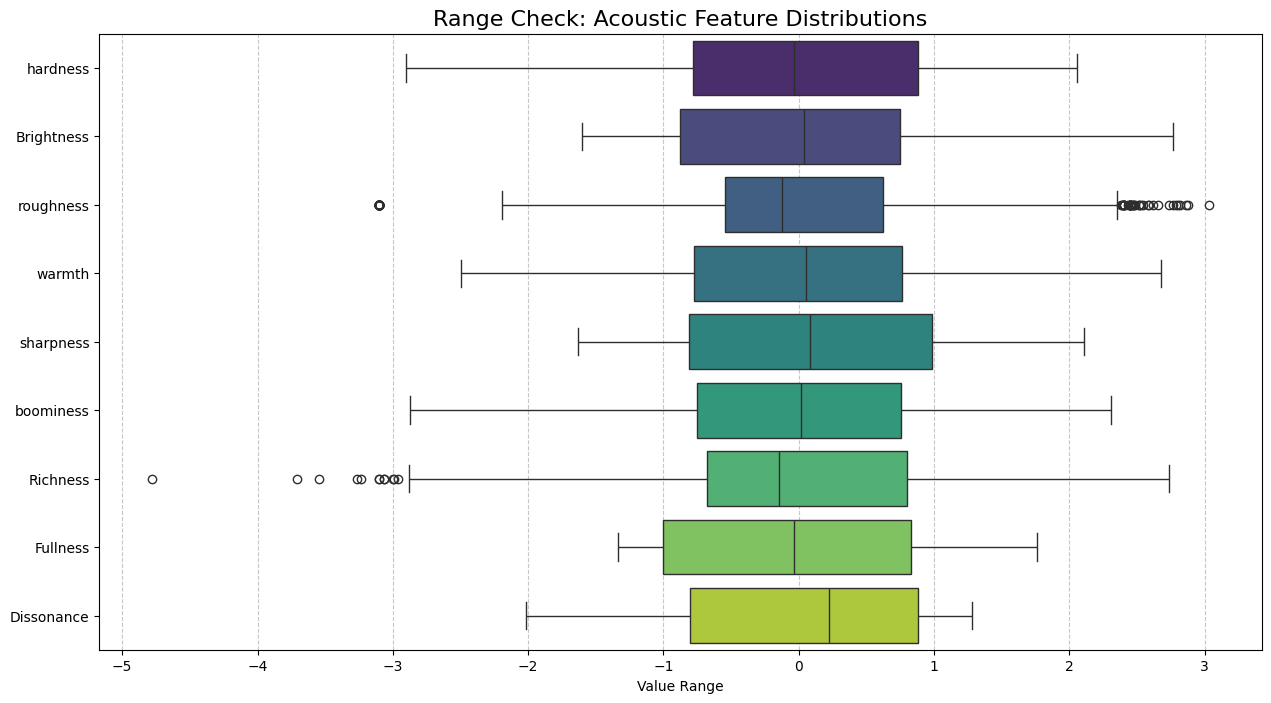

In [64]:


plt.figure(figsize=(15, 8))
sns.boxplot(data=df[label_cols], orient='h', palette='viridis')
plt.title("Range Check: Acoustic Feature Distributions", fontsize=16)
plt.xlabel("Value Range")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

### Correlation Check

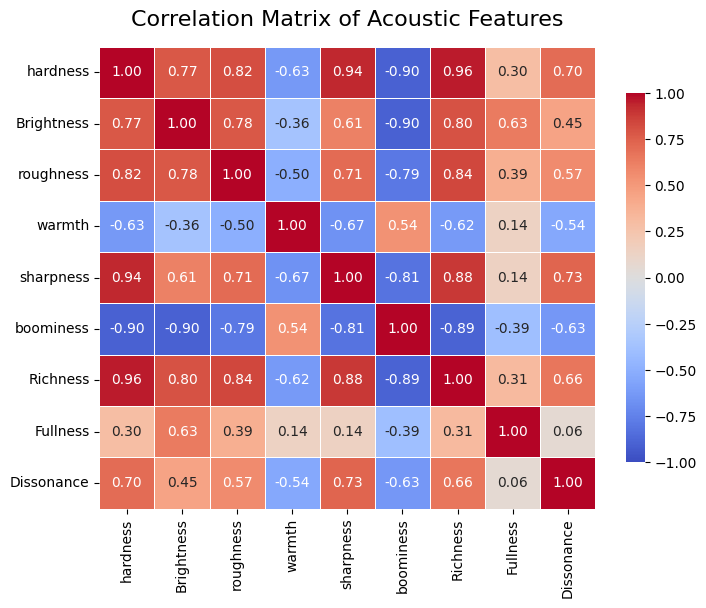

In [65]:
corr_matrix = df[label_cols].corr()


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap="coolwarm",  
            vmin=-1, vmax=1,  
            linewidths=.5,     
            fmt=".2f",         
            cbar_kws={"shrink": .8}) 

plt.title("Correlation Matrix of Acoustic Features", fontsize=16, pad=15)
plt.yticks(rotation=0)  
plt.show()

With the waveforms strictly aligned and the acoustic features (labels) successfully standardized via Z-Score normalization, the dataset is now primed for deep learning. 

Analysis of the relationships between attributes reveals the following trends:

* **Strong Positive Correlation (0.78):** Between **Brightness** and **Richness**. This suggests that brighter sounds tend to be perceived as harmonically richer.
* **Moderate Correlation (0.50 – 0.56):** **Brightness** shows a moderate link with **Fullness** and **Undulation**.
* **Low to Zero Correlation:** **Symmetry** shows almost no correlation with other features (coefficients around 0.0 – 0.15), indicating it is an independent acoustic parameter.

These findings are crucial for the CVAE architecture as they confirm that some labels are redundant/interlinked while others provide unique, orthogonal information.

## Export

In [68]:
df.rename(columns={
    'Dissonance': 'dissonance',
    'Brightness': 'brightness',
    'Richness': 'richness',
    'Fullness': 'fullness'
}, inplace=True)

In [69]:
df.to_pickle('dataset_cvae.pkl')

In [70]:
df.head()

,name,waveform,sample_rate,hardness,roughness,warmth,sharpness,boominess,dissonance,brightness,richness,fullness
0,AKWF_0001,"[tensor(0.0077), tensor(0.0512), tensor(0.0964...",44100,0.111332,0.199850,-0.165995,0.199206,-1.265698,-0.515982,1.043064,-0.185487,1.706681
1,AKWF_0002,"[tensor(-0.0004), tensor(0.0365), tensor(0.080...",44100,-0.005772,-0.352090,0.149635,-0.076211,-0.827317,-1.594595,0.978661,-0.302149,1.545375
2,AKWF_0003,"[tensor(0.0158), tensor(0.0542), tensor(0.0929...",44100,-0.412650,-0.297954,-0.414082,-0.533966,-0.630207,1.263365,0.820740,-0.801659,1.556084
3,AKWF_0004,"[tensor(0.0970), tensor(0.2102), tensor(0.3188...",44100,0.413905,0.438060,0.205963,0.394305,-0.865000,-0.210077,0.809599,0.133011,1.521843
4,AKWF_0005,"[tensor(0.0020), tensor(0.0041), tensor(0.0077...",44100,0.088985,-0.346869,-0.223174,0.710935,0.242829,0.446744,-1.250317,-0.242894,-1.256209


In [ ]:

os.makedirs('dataset', exist_ok=True)
os.makedirs(f"dataset/AKWF_44k1_600s", exist_ok=True)
os.makedirs(f"dataset/AKWF_44k1_600s/AKWF_44k1_600s", exist_ok=True)
os.makedirs(f"dataset/AKWF_44k1_600s/AKWF_44k1_600s/labels", exist_ok=True)

label_cols = ['brightness', 'fullness', 'roughness', 'warmth', 'sharpness', 'boominess', 'richness', 'dissonance', 'hardness']

all_metadata = []

print("Starting Export...")


base_dir = "dataset/AKWF_44k1_600s/AKWF_44k1_600s"
audio_dir = os.path.join(base_dir)  
labels_dir = os.path.join(base_dir, "labels") 

os.makedirs(audio_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)


for index, row in df.iterrows():
    if 'name' in row and str(row['name']).startswith('._'):
        continue
        
    file_id = row['name'] 
    
    wav_filename = f"{file_id}.wav"
    wav_path = os.path.join(audio_dir, wav_filename)
    
    waveform = row['waveform']
    if torch.is_tensor(waveform):
        waveform = waveform.detach().cpu().numpy()
    else:
        waveform = np.array(waveform)
        
    waveform = waveform.astype(np.float32)
    sample_rate = 44100
    wavfile.write(wav_path, sample_rate, waveform)

    json_filename = f"{file_id}_analysis.json"
    json_path = os.path.join(labels_dir, json_filename)
    
    analysis_data = {
        "name": file_id,
        "sample_rate": sample_rate,
        **{col: float(row[col]) for col in label_cols}
    }
    
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(analysis_data, f, indent=4)

print(f"Done")

Starting Export...
Hotovo! Audio je v 'dataset/AKWF_44k1_600s/AKWF_44k1_600s' a analýzy v 'dataset/AKWF_44k1_600s/AKWF_44k1_600s/labels'.
